# Propagation of errors -- symbolic, numeric, object-oriented, complex
### derive it in SymPy, run it in NumPy, wrap it in a class, push it through i

Every measurement has an uncertainty; a formula combines them. To first order the
rule is **the derivative applied to uncertainty**. This notebook:

1. **derives** the propagation formula symbolically (SymPy `init_printing`),
2. **checks** it numerically with `dgs/error_propagation.py`,
3. wraps it in an **object-oriented** `Measurement` class (operators auto-propagate),
4. pushes uncertainty through **imaginary numbers** (a complex field A e^{i phi} ->
   amplitude/phase errors -> the receiver's I/Q), and
5. **applies it to electromagnetism**: the flux-rule emf = B h v error budget.

Civilian education / college prep.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sympy as sp
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import error_propagation as ep
sp.init_printing()
print("ready -- sympy", sp.__version__)

ready -- sympy 1.14.0


## 1. Derive the formula symbolically (SymPy)

For $f(x,y)$ with independent uncertainties $\sigma_x,\sigma_y$, the first-order
variance is
$$\sigma_f^2=\left(\frac{\partial f}{\partial x}\right)^2\sigma_x^2
            +\left(\frac{\partial f}{\partial y}\right)^2\sigma_y^2.$$
Let SymPy take the partials and specialize to the textbook rules.

SUM   f = x + y :


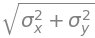

PRODUCT f = x*y :


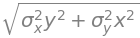

POWER f = x**3  :


relative product error sigma_f/f =


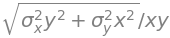

In [2]:
x, y, sx, sy = sp.symbols("x y sigma_x sigma_y", positive=True)

def sigma_f(expr):
    """General first-order propagated sigma for expr(x, y)."""
    var = (sp.diff(expr, x)*sx)**2 + (sp.diff(expr, y)*sy)**2
    return sp.sqrt(sp.simplify(var))

print("SUM   f = x + y :"); display(sigma_f(x + y))           # -> sqrt(sx^2+sy^2)
print("PRODUCT f = x*y :"); display(sp.simplify(sigma_f(x*y)))# -> |xy| sqrt((sx/x)^2+(sy/y)^2)
print("POWER f = x**3  :"); display(sigma_f(x**3))            # -> 3 x^2 sx
# show the product rule in RELATIVE form: sigma_f/f
rel = sp.simplify(sigma_f(x*y) / (x*y))
print("relative product error sigma_f/f ="); display(rel)

## 2. Check it numerically

`ep.propagate` takes the partials **numerically** (central differences) and forms
$g^T\Sigma g$ -- so it works for any `f`, no hand derivation. It must match the
symbolic formula and a Monte-Carlo simulation.

In [3]:
f_prod = lambda p: p[0]*p[1]
val, s_lin = ep.propagate(f_prod, [2.0, 5.0], [0.1, 0.2])
_,   s_mc  = ep.propagate_mc(f_prod, [2.0, 5.0], [0.1, 0.2], n=300_000)
s_sym = float(sp.simplify(sigma_f(x*y)).subs({x:2, y:5, sx:0.1, sy:0.2}))
print(f"product 2*5 = {val:.1f}")
print(f"  symbolic    sigma = {s_sym:.5f}")
print(f"  numerical   sigma = {s_lin:.5f}")
print(f"  Monte Carlo sigma = {s_mc:.5f}   (all three agree)")

product 2*5 = 10.0


  symbolic    sigma = 0.64031
  numerical   sigma = 0.64031
  Monte Carlo sigma = 0.64031   (all three agree)


## 3. Object-oriented: a value that carries its uncertainty

`Measurement` overloads `+ - * / **` so uncertainty propagates as you compute --
the loop over factors reads like ordinary arithmetic, but each step combines the
sigmas. (Independence assumed; correlated inputs need `propagate(cov=...)`.)

In [4]:
M = ep.Measurement
B, h, v = M(0.5, 0.01), M(2.0, 0.05), M(3.0, 0.10)
emf = B * h * v                          # operators auto-propagate
print("emf = B*h*v =", emf, "V")

# a loop "for understanding": multiply a list of measurements, watch sigma grow
factors = [M(2.0, 0.1), M(3.0, 0.15), M(4.0, 0.2), M(5.0, 0.25)]
acc = M(1.0, 0.0)
for i, m in enumerate(factors, 1):
    acc = acc * m
    print(f"  after {i} factors: {acc}  (relative {acc.sigma/acc.value:.3f})")

emf = B*h*v = 3 +/- 0.14 V
  after 1 factors: 2 +/- 0.1  (relative 0.050)
  after 2 factors: 6 +/- 0.42  (relative 0.071)
  after 3 factors: 24 +/- 2.1  (relative 0.087)
  after 4 factors: 120 +/- 12  (relative 0.100)


## 4. Imaginary numbers -- propagating through a complex field

The receiver's signal is a **complex field** $E=A\,e^{i\phi}$: amplitude $A$ and
phase $\phi$, each measured with error. How do those map to the real/imaginary
(I/Q) parts, and to the intensity $I=|E|^2=A^2$? SymPy takes the complex partials;
the key result $\sigma_I=2A\,\sigma_A$ is why low light (small $A$) hurts phase
retrieval.

Re = A cos(phi),  sigma_Re =

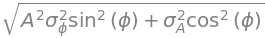

intensity I = A^2,  sigma_I =


=> relative intensity error 2 sigma_A/A; phase error passes through as sigma_phi.

numeric: Re(A=2, phi=0.6) = 1.6507 +/- 0.1000


In [5]:
A, phi, sA, sphi = sp.symbols("A phi sigma_A sigma_phi", positive=True)
Re = A*sp.cos(phi)          # in-phase  (I)
Im = A*sp.sin(phi)          # quadrature (Q)
sig_Re = sp.sqrt(sp.simplify((sp.diff(Re,A)*sA)**2 + (sp.diff(Re,phi)*sphi)**2))
print("Re = A cos(phi),  sigma_Re ="); display(sig_Re)

I_intensity = A**2          # |E|^2
sig_I = sp.sqrt((sp.diff(I_intensity, A)*sA)**2)
print("intensity I = A^2,  sigma_I ="); display(sig_I)   # = 2 A sigma_A
print("=> relative intensity error 2 sigma_A/A; phase error passes through as sigma_phi.")

# numeric: propagate (A, phi) -> Re via ep.propagate
f_Re = lambda p: p[0]*np.cos(p[1])
val, s = ep.propagate(f_Re, [2.0, 0.6], [0.1, 0.05])
print(f"\nnumeric: Re(A=2, phi=0.6) = {val:.4f} +/- {s:.4f}")

## 5. Apply calculus to electromagnetism -- the emf error budget

The flux rule gives $\varepsilon=Bhv$ (Griffiths 7.13). Each measured factor
contributes $\left(\frac{\partial\varepsilon}{\partial x_i}\sigma_i\right)^2$
to the variance. Plotting those contributions shows **which measurement to improve
first** -- here the 10% error on $v$ dominates. That is calculus (partials) turned
into an engineering decision.

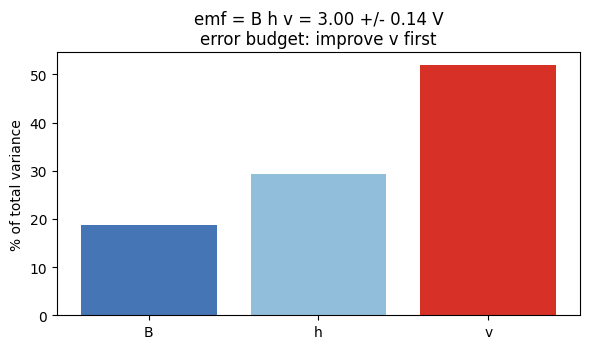

  B:  18.7% of variance
  h:  29.3% of variance
  v:  52.0% of variance


In [6]:
B0, h0, v0 = 0.5, 2.0, 3.0
sigmas = {"B": 0.01, "h": 0.05, "v": 0.10}
emf_f = lambda p: p[0]*p[1]*p[2]
val, s_tot = ep.propagate(emf_f, [B0, h0, v0], list(sigmas.values()))

# variance contribution of each variable: (df/dx_i * sigma_i)^2
g = ep.jacobian(emf_f, [B0, h0, v0])
contrib = (g * np.array(list(sigmas.values())))**2
plt.figure(figsize=(6, 3.6))
plt.bar(list(sigmas.keys()), contrib/contrib.sum()*100,
        color=["#4575b4", "#91bfdb", "#d73027"])
plt.ylabel("% of total variance"); plt.title(f"emf = B h v = {val:.2f} +/- {s_tot:.2f} V\nerror budget: improve v first")
plt.tight_layout(); plt.show()
for k, c in zip(sigmas, contrib):
    print(f"  {k}: {c/contrib.sum()*100:5.1f}% of variance")

## What you proved

1. **Propagation = the derivative applied to uncertainty**: $\sigma_f^2=g^T\Sigma g$.
2. Symbolic (SymPy), numerical (`propagate`), and Monte-Carlo answers **agree**.
3. The rules: sums add **absolute** sigmas in quadrature; products add **relative**
   sigmas; powers scale the relative error by $|n|$.
4. The OOP `Measurement` class makes it automatic; complex fields split into I/Q
   with $\sigma_I=2A\sigma_A$ (low-light penalty).
5. The **error budget** turns partials into a decision: fix the dominant term.

One idea -- the derivative -- runs from a SymPy formula to a measured-emf error bar.
Civilian education.